### Imports

In [2]:
import os
from pathlib import Path
import torch
import matplotlib.patches as patches
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch.nn.functional as F


### Loading kedro

In [3]:
os.chdir("../../")

%load_ext kedro.ipython

[05/01/26 12:19:12] INFO     Using                                                                  ]8;id=828953;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=837443;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\framework\project\__init__.py#269\269]8;;\
                             'c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-pac                
                             kages\kedro\framework\project\rich_logging.yml' as logging                            
                             configuration.                                                                        

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=406764;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=671997;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#64\64]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=555707;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=953652;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#66\66]8;;\

                    INFO     Resolved project path as:                                              ]8;id=329072;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=109636;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#181\181]8;;\
                             c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\cxr-training-pipeli                
                             ne.                                                                                   
                             To set a different path, run '%reload_kedro <project_root>'                           

[05/01/26 12:19:16] WARNING  c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-pack ]8;id=94476;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=369294;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             ages\requests\__init__.py:113: RequestsDependencyWarning: urllib3                     
                             (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't                   
                             match a supported version!                                                            
                               warnings.warn(                                                                      
                                                                                                                   

...

                    WARNING  c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-pack ]8;id=386655;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=523848;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             ages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning:                   
                             The filesystem tracking backend (e.g., './mlruns') is deprecated as of                
                             February 2026. Consider transitioning to a database backend (e.g.,                    
                             'sqlite:///mlflow.db') to take advantage of the latest MLflow                         
                             features. See                                                                         
                             https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store                   
                             for migration guidance.                                                               
                               return FileStore(store_uri, store_uri)                                              
                                                                                                                   

[05/01/26 12:19:54] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=409409;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=537000;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro_telemetry\plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

[05/01/26 12:19:55] INFO     Kedro project cxr-training-pipeline                                    ]8;id=250199;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=637113;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#147\147]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=620749;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=148109;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#148\148]8;;\
                             'pipelines'                                                                           

                    INFO     Registered line magic 'run_viz'                                        ]8;id=47961;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=225517;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\ipython\__init__.py#154\154]8;;\

### Loading model

In [4]:
from src.cxr_training_pipeline.models.paper_based.classifier import CXRClassifier
from src.cxr_training_pipeline.models.resnet_backbone import ResNet50Backbone

In [5]:
backbone = ResNet50Backbone(pretrained=False, grayscale=True)
model = CXRClassifier(num_classes=14, backbone=backbone)

checkpoint_path = "data/06_models/cxr-classification-paper-resnet50_224_40_epochs/baseline_march/checkpoints/best-epoch=39.ckpt"

checkpoint = torch.load(checkpoint_path, map_location="cpu")
state_dict = {
    k.replace("model.", ""): v
    for k, v in checkpoint["state_dict"].items()
    if k.startswith("model.")
}

model.load_state_dict(state_dict)
model.eval()


[05/01/26 12:19:58] WARNING  C:\Users\barte\AppData\Local\Temp\ipykernel_27800\3374714210.py:6:     ]8;id=283689;file://C:\Python312\Lib\warnings.py\warnings.py]8;;\:]8;id=594164;file://C:\Python312\Lib\warnings.py#112\112]8;;\
                             FutureWarning: You are using `torch.load` with `weights_only=False`                   
                             (the current default value), which uses the default pickle module                     
                             implicitly. It is possible to construct malicious pickle data which                   
                             will execute arbitrary code during unpickling (See                                    
                             https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-mod                
                             els for more details). In a future release, the default value for                     
                             `weights_only` will be flipped to `True`. This limits the functions                   
                             that could be executed during unpickling. Arbitrary objects will no                   
                             longer be allowed to be loaded via this mode unless they are                          
                             explicitly allowlisted by the user via                                                
                             `torch.serialization.add_safe_globals`. We recommend you start setting                
                             `weights_only=True` for any use case where you don't have full control                
                             of the loaded file. Please open an issue on GitHub for any issues                     
                             related to this experimental feature.                                                 
                               checkpoint = torch.load(checkpoint_path, map_location="cpu")                        
                                                                                                                   


CXRClassifier(
  (backbone): ResNet50Backbone(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequ

### Creating cropped image

In [6]:
from src.cxr_training_pipeline.utils.segmentation_utils import (
    get_combined_mask_by_image_index,
    crop_resize_with_mask,
)


In [7]:
xray_test = catalog.load("xray_test")
segmentation_masks = catalog.load("cxr8_segmentation_masks")

[05/01/26 12:19:59] INFO     Loading data from xray_test (CSVDataset)...                       ]8;id=48998;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=83466;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

                    INFO     Loading data from cxr8_segmentation_masks (CSVDataset)...         ]8;id=322433;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=272437;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

Image index: 00013118_008.png
True targets: ['Atelectasis']
Cropped tensor shape: (1, 1, 224, 224)


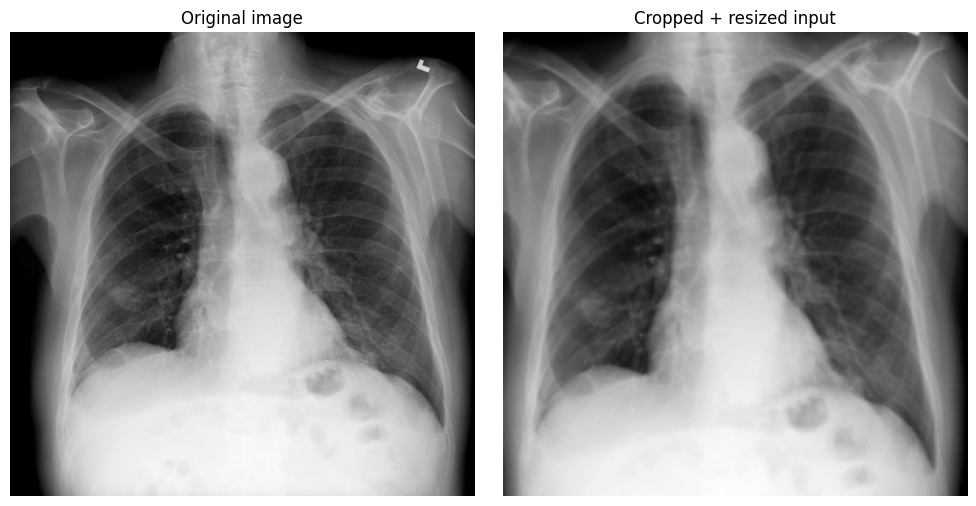

In [8]:
PATHOLOGY_LIST = [
    "Infiltration",
    "Effusion",
    "Atelectasis",
    "Nodule",
    "Mass",
    "Pneumothorax",
    "Consolidation",
    "Pleural_Thickening",
    "Cardiomegaly",
    "Emphysema",
    "Edema",
    "Fibrosis",
    "Pneumonia",
    "Hernia",
]

OUTPUT_SIZE = 224
MARGIN_RATIO = 0.08
MIN_BBOX_SIZE = 64
SAMPLE_IDX = 0
SAMPLE_BBOX = 9376


sample_row = xray_test.iloc[SAMPLE_BBOX]
image_index = str(sample_row["image_index"])
image_path = Path("data/01_raw/images") / image_index

with Image.open(image_path) as img:
    img_original = img.convert("L")

img_np = np.array(img_original, dtype=np.uint8)
cropped_np, bbox_coords = crop_resize_with_mask(
    img_np=img_np,
    image_index=image_index,
    segmentation_masks_df=segmentation_masks,
    output_size=OUTPUT_SIZE,
    margin_ratio=MARGIN_RATIO,
    min_bbox_size=MIN_BBOX_SIZE,
)

image_tensor = torch.from_numpy(cropped_np).float().unsqueeze(0).unsqueeze(0) / 255.0
true_targets = [d for d in PATHOLOGY_LIST if sample_row[d] == 1]

print(f"Image index: {image_index}")
print(f"True targets: {true_targets if true_targets else '(none)'}")
print(f"Cropped tensor shape: {tuple(image_tensor.shape)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_np, cmap="gray")
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(cropped_np, cmap="gray")
axes[1].set_title("Cropped + resized input")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [9]:
SAMPLE_IDX_WITH_BBOX = xray_test["image_index"] == "00013118_008.png"

In [10]:
SAMPLE_IDX_WITH_BBOX.loc[SAMPLE_IDX_WITH_BBOX]


9376    True
Name: image_index, dtype: boolean

In [11]:
xray_test.iloc[9376]


image_index           00013118_008.png
finding_labels             Atelectasis
patient_age                         69
patient_sex                          M
view_position                       PA
Infiltration                         0
Effusion                             0
Atelectasis                          1
Nodule                               0
Mass                                 0
Pneumothorax                         0
Consolidation                        0
Pleural_Thickening                   0
Cardiomegaly                         0
Emphysema                            0
Edema                                0
Fibrosis                             0
Pneumonia                            0
Hernia                               0
Name: 9376, dtype: object

### Predict + resize to the original shape

All predictions:
           Disease  Probability
      Infiltration          1.0
       Atelectasis          1.0
     Consolidation          1.0
          Effusion          0.0
              Mass          0.0
            Nodule          0.0
      Pneumothorax          0.0
Pleural_Thickening          0.0
      Cardiomegaly          0.0
         Emphysema          0.0
             Edema          0.0
          Fibrosis          0.0
         Pneumonia          0.0
            Hernia          0.0


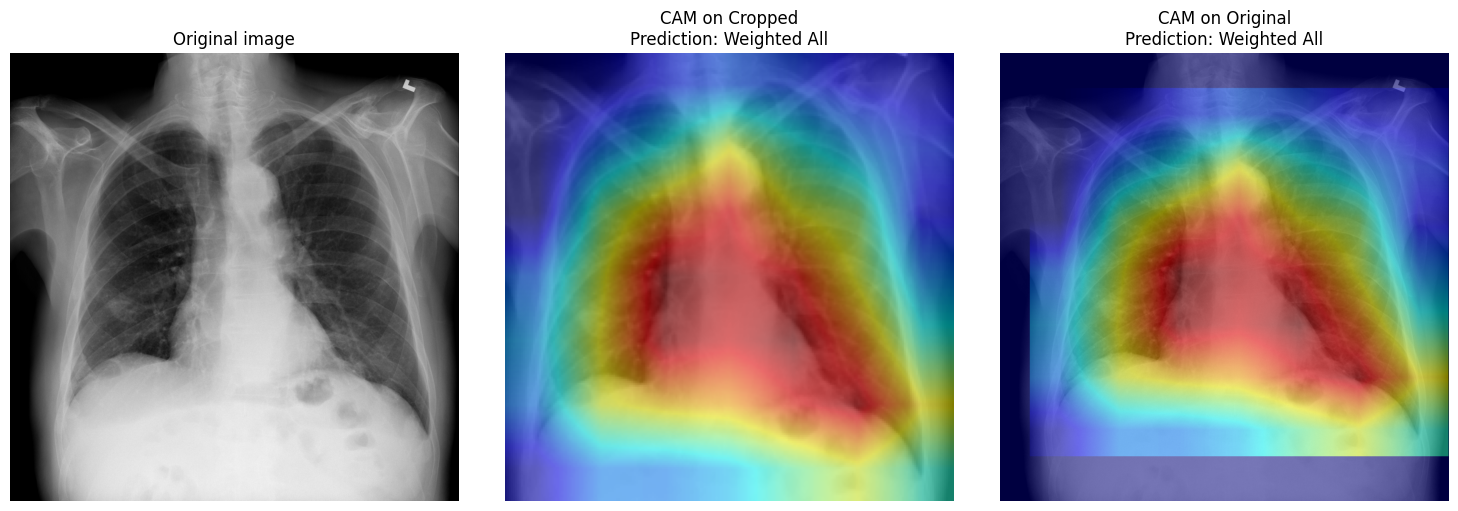

In [12]:
with torch.no_grad():
    out = model(image_tensor)

logits = out['logits'][0]
probs = torch.sigmoid(logits).numpy()


predictions_df = pd.DataFrame({'Disease': PATHOLOGY_LIST, 'Probability': probs}).sort_values(by='Probability', ascending=False)
print("All predictions:")
print(predictions_df.to_string(index=False))


cam = np.zeros_like(out['transition_maps'][0, 0].cpu().numpy())
for i in range(len(PATHOLOGY_LIST)):
    class_cam = out['transition_maps'][0, i].cpu().numpy()
    cam += probs[i] * class_cam

cam = np.maximum(cam, 0)
cam = cam / (cam.max() + 1e-8)

pred_label = "Weighted All"


cam_cropped = cv2.resize(cam, (OUTPUT_SIZE, OUTPUT_SIZE))
heatmap_cropped = cv2.applyColorMap(np.uint8(255 * cam_cropped), cv2.COLORMAP_JET)
heatmap_cropped = cv2.cvtColor(heatmap_cropped, cv2.COLOR_BGR2RGB)

cropped_rgb = cv2.cvtColor(cropped_np, cv2.COLOR_GRAY2RGB)
overlay_cropped = cv2.addWeighted(cropped_rgb, 0.5, heatmap_cropped, 0.5, 0)


cam_original_full = np.zeros_like(img_np, dtype=np.float32)

if bbox_coords is not None:
    x_min, y_min, x_max, y_max = bbox_coords
    bbox_w = x_max - x_min
    bbox_h = y_max - y_min

    cam_bbox = cv2.resize(cam, (bbox_w, bbox_h))
    cam_original_full[y_min:y_max, x_min:x_max] = cam_bbox

heatmap_original = cv2.applyColorMap(np.uint8(255 * cam_original_full), cv2.COLORMAP_JET)
heatmap_original = cv2.cvtColor(heatmap_original, cv2.COLOR_BGR2RGB)

img_original_rgb = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)
overlay_original = cv2.addWeighted(img_original_rgb, 0.5, heatmap_original, 0.5, 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_original_rgb)
axes[0].set_title("Original image")
axes[0].axis("off")

axes[1].imshow(overlay_cropped)
axes[1].set_title(f"CAM on Cropped\nPrediction: {pred_label}")
axes[1].axis("off")

axes[2].imshow(overlay_original)
axes[2].set_title(f"CAM on Original\nPrediction: {pred_label}")
axes[2].axis("off")

plt.tight_layout()
plt.show()


In [13]:
xray_test.iloc[SAMPLE_BBOX]


image_index           00013118_008.png
finding_labels             Atelectasis
patient_age                         69
patient_sex                          M
view_position                       PA
Infiltration                         0
Effusion                             0
Atelectasis                          1
Nodule                               0
Mass                                 0
Pneumothorax                         0
Consolidation                        0
Pleural_Thickening                   0
Cardiomegaly                         0
Emphysema                            0
Edema                                0
Fibrosis                             0
Pneumonia                            0
Hernia                               0
Name: 9376, dtype: object

In [14]:
bbox = catalog.load("cxr8_bbox")

[05/01/26 12:20:49] INFO     Loading data from cxr8_bbox (CSVDataset)...                       ]8;id=216309;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=135516;file://c:\Users\barte\OneDrive\Pulpit\dnn-cxr-diagnostics\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

In [15]:
bbox[bbox["image_index"] == image_index]

,image_index,finding_label,x,y,w,h
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441


In [16]:
bbox.head()

,image_index,finding_label,x,y,w,h
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695


### Writing bbox

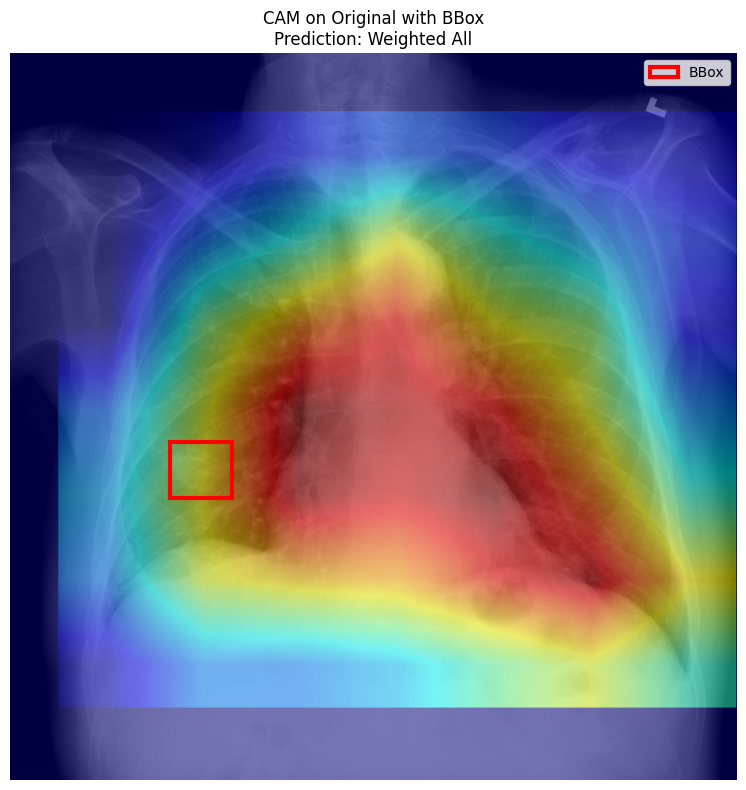

In [17]:
img_bboxes = bbox[bbox["image_index"] == image_index]

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

ax.imshow(overlay_original)
ax.set_title(f"CAM on Original with BBox\nPrediction: {pred_label}")
ax.axis("off")

for _, row in img_bboxes.iterrows():
    x = row["Bbox [x]"] if "Bbox [x]" in row else row.get("x", 0)
    y = row["Bbox [y]"] if "Bbox [y]" in row else row.get("y", 0)
    w = row["Bbox [w]"] if "Bbox [w]" in row else row.get("w", 0)
    h = row["Bbox [h]"] if "Bbox [h]" in row else row.get("h", 0)

    if pd.notna(x) and pd.notna(y) and pd.notna(w) and pd.notna(h):
        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=3,
            edgecolor='red',
            facecolor='none',
            label=row.get('Finding Label', 'BBox')
        )
        ax.add_patch(rect)

if not img_bboxes.empty:
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

### Prediction on masked_image

Predictions on Masked & Cropped Image:
           Disease  Probability
      Infiltration          1.0
       Atelectasis          1.0
     Consolidation          1.0
          Effusion          0.0
              Mass          0.0
            Nodule          0.0
      Pneumothorax          0.0
Pleural_Thickening          0.0
      Cardiomegaly          0.0
         Emphysema          0.0
             Edema          0.0
          Fibrosis          0.0
         Pneumonia          0.0
            Hernia          0.0


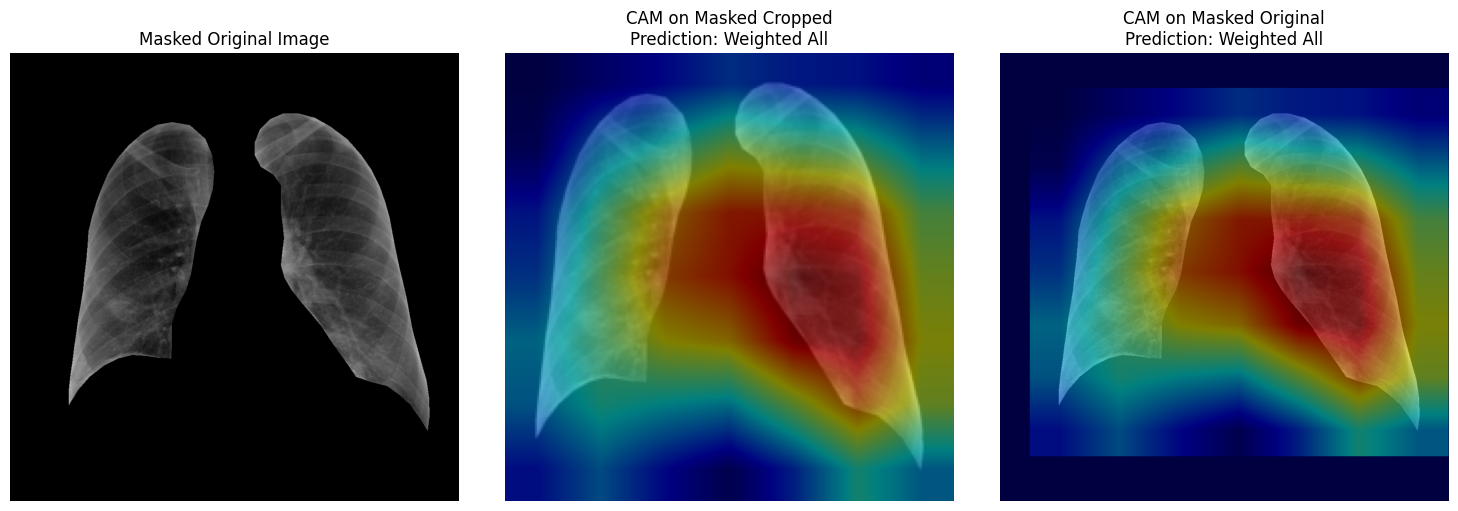

In [18]:
combined_mask = get_combined_mask_by_image_index(
    image_index=image_index,
    segmentation_masks_df=segmentation_masks,
    height=img_np.shape[0],
    width=img_np.shape[1],
    mask_columns=['Left Lung', 'Right Lung']
)


masked_img_np = img_np * combined_mask

masked_cropped_np, masked_bbox_coords = crop_resize_with_mask(
    img_np=masked_img_np,
    image_index=image_index,
    segmentation_masks_df=segmentation_masks,
    output_size=OUTPUT_SIZE,
    margin_ratio=MARGIN_RATIO,
    min_bbox_size=MIN_BBOX_SIZE,
)


masked_image_tensor = torch.from_numpy(masked_cropped_np).float().unsqueeze(0).unsqueeze(0) / 255.0


with torch.no_grad():
    masked_out = model(masked_image_tensor)

masked_probs = torch.sigmoid(masked_out['logits'][0]).numpy()


masked_predictions_df = pd.DataFrame({
    'Disease': PATHOLOGY_LIST,
    'Probability': masked_probs
}).sort_values(by='Probability', ascending=False)

print("Predictions on Masked & Cropped Image:")
print(masked_predictions_df.to_string(index=False))


masked_cam = np.zeros_like(masked_out['transition_maps'][0, 0].cpu().numpy())
for i in range(len(PATHOLOGY_LIST)):
    class_cam = masked_out['transition_maps'][0, i].cpu().numpy()
    masked_cam += masked_probs[i] * class_cam

masked_cam = np.maximum(masked_cam, 0)
masked_cam = masked_cam / (masked_cam.max() + 1e-8)

pred_label = "Weighted All"


masked_cam_cropped = cv2.resize(masked_cam, (OUTPUT_SIZE, OUTPUT_SIZE))
heatmap_masked_cropped = cv2.applyColorMap(np.uint8(255 * masked_cam_cropped), cv2.COLORMAP_JET)
heatmap_masked_cropped = cv2.cvtColor(heatmap_masked_cropped, cv2.COLOR_BGR2RGB)

masked_cropped_rgb = cv2.cvtColor(masked_cropped_np, cv2.COLOR_GRAY2RGB)
overlay_masked_cropped = cv2.addWeighted(masked_cropped_rgb, 0.5, heatmap_masked_cropped, 0.5, 0)


masked_cam_original_full = np.zeros_like(masked_img_np, dtype=np.float32)

if masked_bbox_coords is not None:
    x_min, y_min, x_max, y_max = masked_bbox_coords
    bbox_w = x_max - x_min
    bbox_h = y_max - y_min

    masked_cam_bbox = cv2.resize(masked_cam, (bbox_w, bbox_h))
    masked_cam_original_full[y_min:y_max, x_min:x_max] = masked_cam_bbox

heatmap_masked_original = cv2.applyColorMap(np.uint8(255 * masked_cam_original_full), cv2.COLORMAP_JET)
heatmap_masked_original = cv2.cvtColor(heatmap_masked_original, cv2.COLOR_BGR2RGB)

img_masked_original_rgb = cv2.cvtColor(masked_img_np, cv2.COLOR_GRAY2RGB)
overlay_masked_original = cv2.addWeighted(img_masked_original_rgb, 0.5, heatmap_masked_original, 0.5, 0)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_masked_original_rgb)
axes[0].set_title("Masked Original Image")
axes[0].axis("off")

axes[1].imshow(overlay_masked_cropped)
axes[1].set_title(f"CAM on Masked Cropped\nPrediction: {pred_label}")
axes[1].axis("off")

axes[2].imshow(overlay_masked_original)
axes[2].set_title(f"CAM on Masked Original\nPrediction: {pred_label}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Conclusions

- Model used for this quick test was trained on images which which were not cropped before training.
- We need to compare results with model trained on cropped images, as well as on model which was trained on cropped images with masks